# Exploratory Data Analysis (EDA)

В этом ноутбуке мы проведем анализ данных из набора EnterpriseRAG-Bench.

In [22]:
!pip install seaborn


In [23]:
# Импортируем необходимые библиотеки
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')

# Загружаем данные
ds_q = load_dataset("onyx-dot-app/EnterpriseRAG-Bench", "questions")
ds_d = load_dataset("onyx-dot-app/EnterpriseRAG-Bench", "documents")

## Преобразование Dataset в DataFrame

Преобразуем Dataset в pandas DataFrame для удобства анализа.

In [24]:
# Преобразование Dataset в DataFrame
# Для этого используем метод to_pandas()
df_documents = ds_d['test'].to_pandas()
df_questions = ds_q['test'].to_pandas()

# Посмотрим на структуру данных
print("Размерность df_documents:", df_documents.shape)
print("Размерность df_questions:", df_questions.shape)

Размерность df_documents: (511962, 4)
Размерность df_questions: (500, 7)


## Базовая информация о данных

Посмотрим основную информацию о данных.

In [25]:
# Основная информация о документах
print("=== Информация о документах ===")
print(df_documents.info())
print("\nПервые 5 строк документов:")
print(df_documents.head())

print("\n\n=== Информация о вопросах ===")
print(df_questions.info())
print("\nПервые 5 строк вопросов:")
print(df_questions.head())

=== Информация о документах ===
<class 'pandas.DataFrame'>
RangeIndex: 511962 entries, 0 to 511961
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   doc_id       511962 non-null  str  
 1   source_type  511962 non-null  str  
 2   title        511962 non-null  str  
 3   content      511962 non-null  str  
dtypes: str(4)
memory usage: 2.4 GB
None

Первые 5 строк документов:
                                  doc_id source_type  \
0  dsid_e54ef48bae78474684a957cf613d47d5  confluence   
1  dsid_229dd48e9b1d466a81ebaffe3ec84469  confluence   
2  dsid_aeb0022d62bc43beb6549ba92e5655eb  confluence   
3  dsid_926174fc4900408c89c98abde46b7225  confluence   
4  dsid_d511c6d8daf94f998ce6a3d97462af2d  confluence   

                                               title  \
0  Runbook: Deploy / Upgrade / Roll Back perf-can...   
1  Cross-account GPU burst SLO contract and CI li...   
2  Third-Party & Vendor Coordination Playbook for

## Описательная статистика

Посмотрим основные статистические характеристики данных.

In [26]:
# Описательная статистика для числовых столбцов
print("=== Описательная статистика для документов ===")
print(df_documents.describe())

print("\n\n=== Описательная статистика для вопросов ===")
print(df_questions.describe())

=== Описательная статистика для документов ===
                                       doc_id source_type      title  \
count                                  511962      511962     511962   
unique                                 511958           9     237556   
top     dsid_8a0c5430bac64f8da21c2cee5a7f4df5       slack  incidents   
freq                                        2      285605      24044   

                                                  content  
count                                              511962  
unique                                             510598  
top     morgan: Quick design check — on the Create Dep...  
freq                                                    3  


=== Описательная статистика для вопросов ===
       question_id question_type  source_types  \
count          500           500           500   
unique         500            10           107   
top       qst_0001         basic  [confluence]   
freq             1           175            6

## Проверка пропущенных значений

Проверим наличие пропущенных значений в данных.

In [27]:
# Проверка пропущенных значений
print("=== Пропущенные значения в документах ===")
print(df_documents.isnull().sum())

print("\n\n=== Пропущенные значения в вопросах ===")
print(df_questions.isnull().sum())

=== Пропущенные значения в документах ===
doc_id         0
source_type    0
title          0
content        0
dtype: int64


=== Пропущенные значения в вопросах ===
question_id         0
question_type       0
source_types        0
question            0
expected_doc_ids    0
gold_answer         0
answer_facts        0
dtype: int64


## Анализ текстовых данных

Проанализируем длину текстов в документах и вопросах.

In [28]:
# Добавим столбцы с длиной текстов
df_documents['doc_length'] = df_documents['content'].str.len()
df_questions['question_length'] = df_questions['question'].str.len()

# Статистика по длине текстов
print("=== Статистика по длине документов ===")
print(df_documents['doc_length'].describe())

print("\n\n=== Статистика по длине вопросов ===")
print(df_questions['question_length'].describe())

=== Статистика по длине документов ===
count    511962.000000
mean       4814.786982
std        2412.050031
min           0.000000
25%        2989.000000
50%        4276.000000
75%        6400.000000
max       41317.000000
Name: doc_length, dtype: float64


=== Статистика по длине вопросов ===
count    500.000000
mean     195.436000
std       66.650239
min       46.000000
25%      149.750000
50%      184.000000
75%      238.000000
max      457.000000
Name: question_length, dtype: float64


## Визуализация данных

Построим графики для лучшего понимания распределения данных.

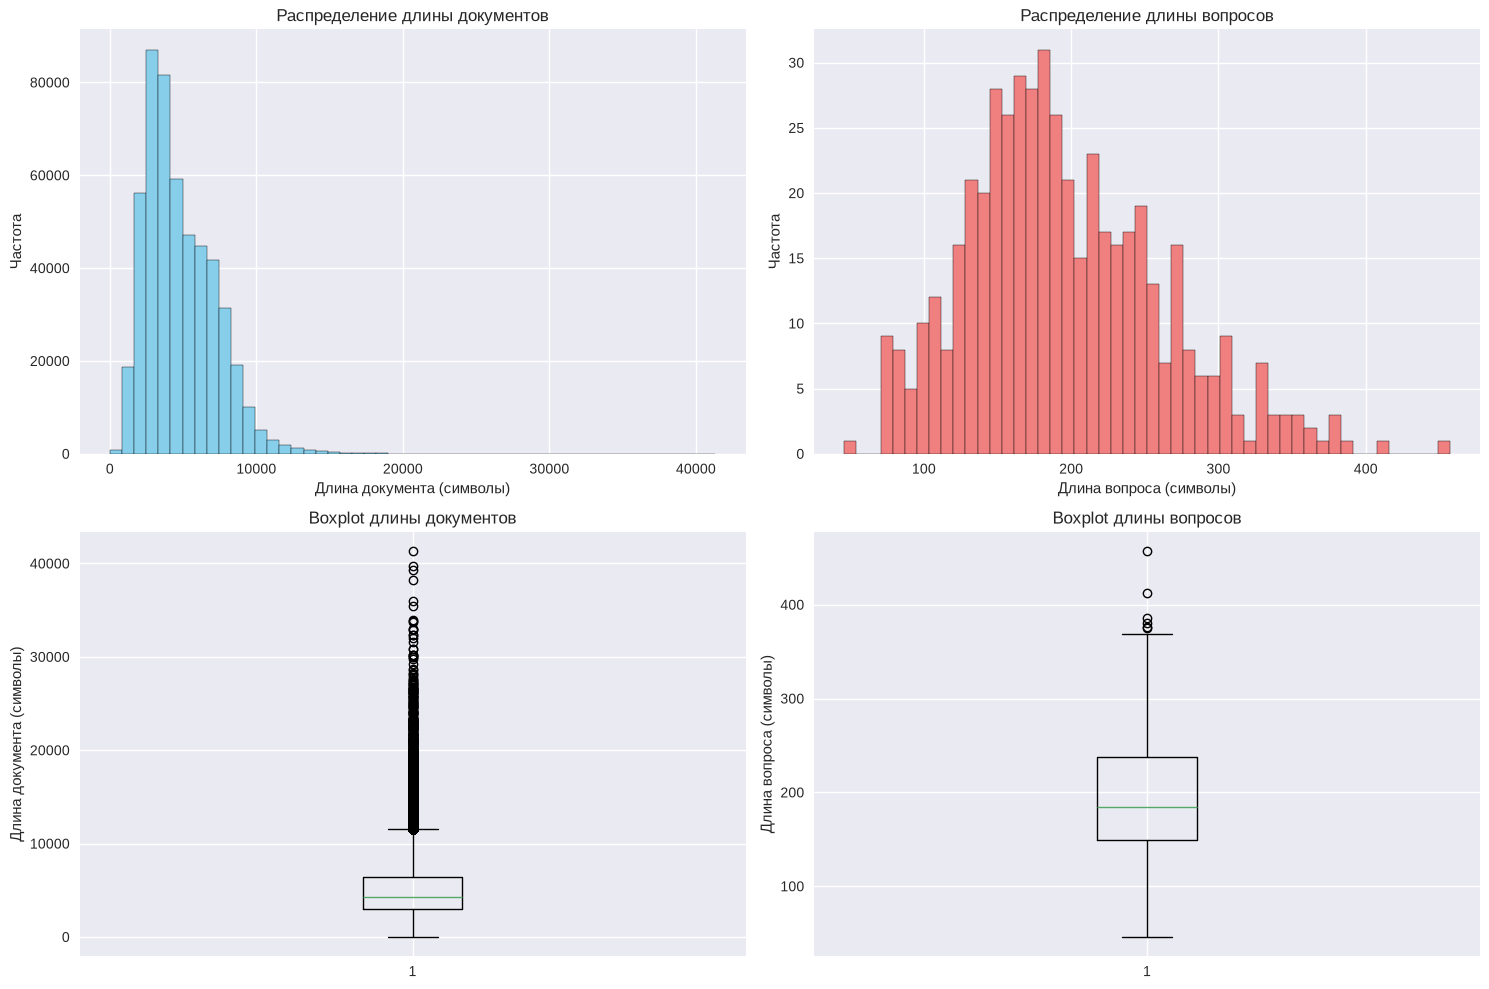

In [29]:
# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Распределение длины документов
axes[0, 0].hist(df_documents['doc_length'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Распределение длины документов')
axes[0, 0].set_xlabel('Длина документа (символы)')
axes[0, 0].set_ylabel('Частота')

# Распределение длины вопросов
axes[0, 1].hist(df_questions['question_length'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Распределение длины вопросов')
axes[0, 1].set_xlabel('Длина вопроса (символы)')
axes[0, 1].set_ylabel('Частота')

# Boxplot для длины документов
axes[1, 0].boxplot(df_documents['doc_length'])
axes[1, 0].set_title('Boxplot длины документов')
axes[1, 0].set_ylabel('Длина документа (символы)')

# Boxplot для длины вопросов
axes[1, 1].boxplot(df_questions['question_length'])
axes[1, 1].set_title('Boxplot длины вопросов')
axes[1, 1].set_ylabel('Длина вопроса (символы)')

plt.tight_layout()
plt.show()

## Дополнительный анализ

Посмотрим на примеры документов и вопросов.

In [30]:
# Примеры документов
print("=== Примеры документов ===")
for i in range(min(3, len(df_documents))):
    print(f"Документ {i+1} (ID: {df_documents.iloc[i]['doc_id']}):")
    print(df_documents.iloc[i]['content'][:500] + "..." if len(df_documents.iloc[i]['content']) > 500 else df_documents.iloc[i]['content'])
    print()

# Примеры вопросов
print("=== Примеры вопросов ===")
for i in range(min(3, len(df_questions))):
    print(f"Вопрос {i+1} (ID: {df_questions.iloc[i]['question_id']}):")
    print(df_questions.iloc[i]['question'])
    print()

=== Примеры документов ===
Документ 1 (ID: dsid_e54ef48bae78474684a957cf613d47d5):
## Purpose
This runbook describes the operational procedures to deploy, upgrade, roll back, and safely disable the **perf-canary** service across regions.

perf-canary is a lightweight, always-on synthetic workload that calls internal inference endpoints for a curated model set and emits performance metrics (p50/p95/p99, tokens/sec, prefill/decode, queueing time, batch stats). The service must stay under the defined overhead budget and must not capture or emit customer data.

**Primary users:** ...

Документ 2 (ID: dsid_229dd48e9b1d466a81ebaffe3ec84469):
Summary

Overview:
This document defines the operational contract (SLOs, quotas, billing guardrails) and the CI/CD lifecycle for the cross-account GPU burst fabric. It is intended for platform engineers, tenant owners, and on-call responders who coordinate cross-account bursting between Redwood-managed GPU pools and partner or tenant cloud accounts.

Goa

## Анализ по типам источников (source_type)

Посмотрим на распределение данных по различным типам источников.

In [31]:
# Проверим количество уникальных значений в source_type
print("Уникальные значения source_type:")
print(df_documents['source_type'].value_counts())
print(f"\nВсего уникальных source_type: {df_documents['source_type'].nunique()}")

Уникальные значения source_type:
source_type
slack           285605
gmail           121390
linear           35308
google_drive     25108
hubspot          15017
fireflies        10173
github            8052
jira              6120
confluence        5189
Name: count, dtype: int64

Всего уникальных source_type: 9


### Распределение длин текстов по каждому типу источника

Построим графики распределения длин текстов для каждого из типов источников.

Найдено 9 различных типов источников:
<ArrowStringArray>
[  'confluence',    'fireflies',       'github',        'gmail',
 'google_drive',      'hubspot',         'jira',       'linear',
        'slack']
Length: 9, dtype: str


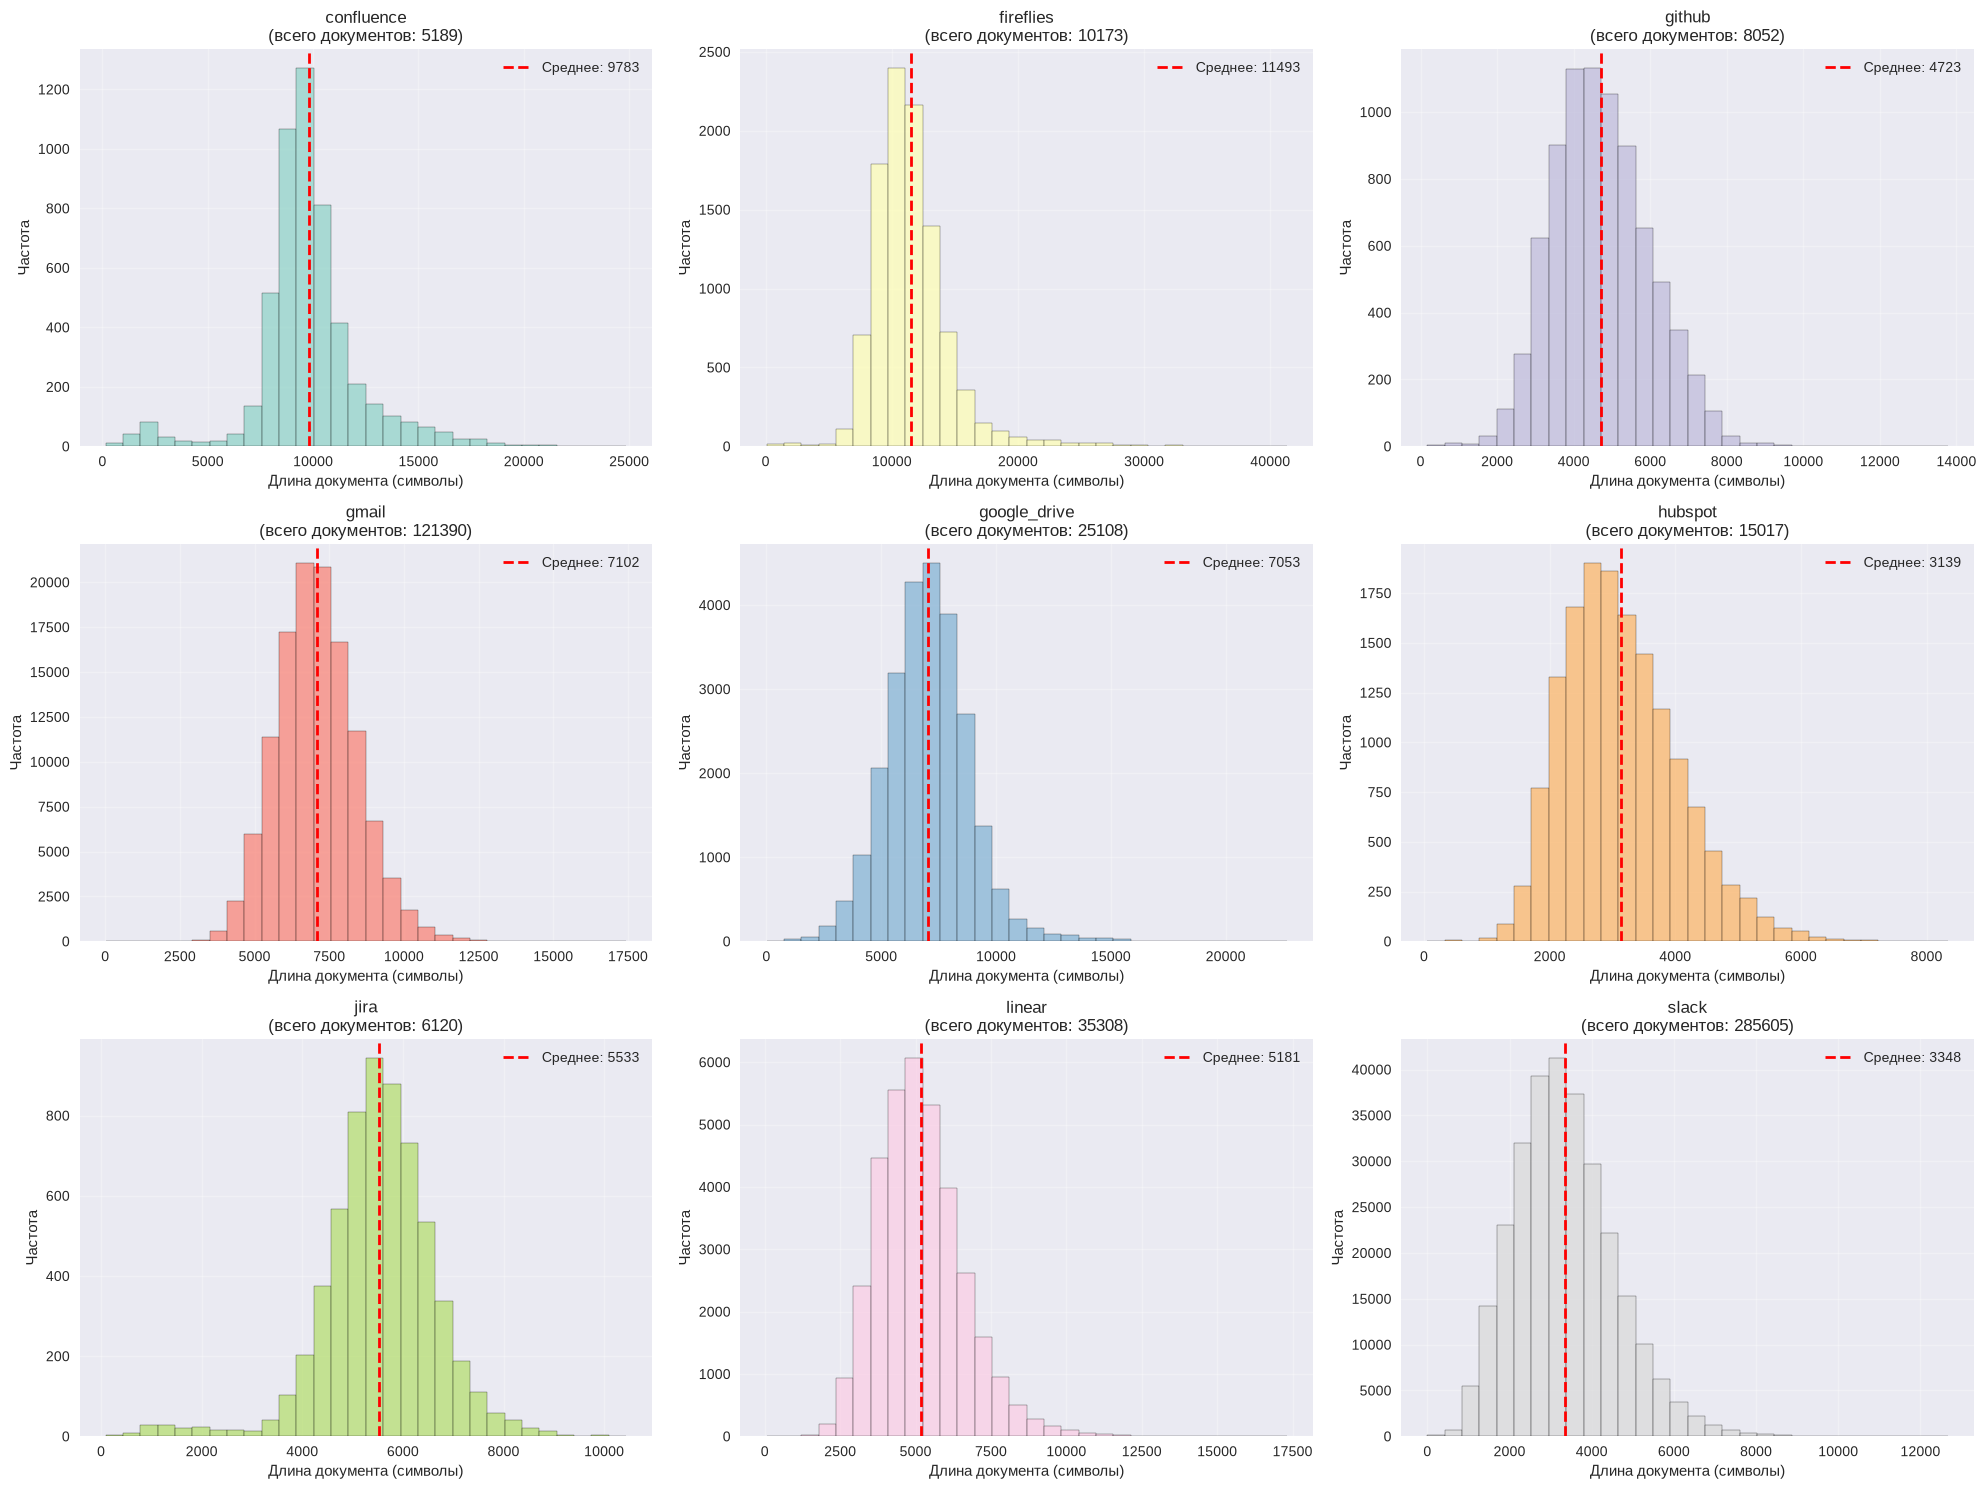


Статистика по длине документов для каждого типа источника:

confluence (документов: 5189):
count     5189.000000
mean      9782.680671
std       2492.201233
min        151.000000
25%       8742.000000
50%       9579.000000
75%      10653.000000
max      24851.000000
Name: doc_length, dtype: float64

fireflies (документов: 10173):
count    10173.000000
mean     11493.004423
std       3095.275461
min         67.000000
25%       9619.000000
50%      11080.000000
75%      12770.000000
max      41317.000000
Name: doc_length, dtype: float64

github (документов: 8052):
count     8052.000000
mean      4723.457154
std       1264.160300
min        177.000000
25%       3822.750000
50%       4616.000000
75%       5537.000000
max      13773.000000
Name: doc_length, dtype: float64

gmail (документов: 121390):
count    121390.000000
mean       7101.976530
std        1350.438126
min          13.000000
25%        6178.000000
50%        7036.000000
75%        7946.000000
max       17435.000000
Name: do

In [32]:
# Получим уникальные значения source_type
source_types = df_documents['source_type'].unique()
print(f"Найдено {len(source_types)} различных типов источников:\n{source_types}")

# Создадим графики для каждого типа источника
n_types = len(source_types)
cols = 3
rows = (n_types + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten() if n_types > 1 else [axes]

for i, stype in enumerate(source_types):
    # Фильтруем данные по типу источника
    filtered_data = df_documents[df_documents['source_type'] == stype]
    
    # Строим гистограмму длин текстов
    axes[i].hist(filtered_data['doc_length'], bins=30, color=plt.cm.Set3(i), alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{stype}\n(всего документов: {len(filtered_data)})')
    axes[i].set_xlabel('Длина документа (символы)')
    axes[i].set_ylabel('Частота')
    axes[i].grid(True, alpha=0.3)
    
    # Добавляем статистику на график
    mean_length = filtered_data['doc_length'].mean()
    axes[i].axvline(mean_length, color='red', linestyle='--', linewidth=2, 
                    label=f'Среднее: {mean_length:.0f}')
    axes[i].legend()

# Удаляем пустые subplot'ы, если они есть
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

# Выведем числовую статистику для каждого типа источника
print("\nСтатистика по длине документов для каждого типа источника:")
for stype in source_types:
    filtered_data = df_documents[df_documents['source_type'] == stype]
    print(f"\n{stype} (документов: {len(filtered_data)}):")
    print(filtered_data['doc_length'].describe())

### Выводы по анализу типов источников

На основе проведенного анализа можно сделать следующие выводы:

1. В данных присутствуют различные типы источников, каждый из которых может иметь свои особенности
2. Распределение длин текстов может значительно отличаться между различными типами источников
3. Некоторые типы источников могут содержать преимущественно короткие тексты, а другие - длинные
4. Средняя длина текстов и их вариативность также различаются между типами источников

Эта информация может быть полезна при дальнейшей работе с данными, например, при выборе стратегии обработки текстов разных типов или при построении моделей машинного обучения.

## Выводы

На основе проведенного анализа можно сделать следующие выводы:

1. Мы успешно преобразовали Dataset в pandas DataFrame с помощью метода `.to_pandas()`
2. Провели базовый EDA, включая:
   - Получение информации о структуре данных
   - Анализ описательной статистики
   - Проверку пропущенных значений
   - Анализ длины текстов
   - Визуализацию распределений
   - Просмотр примеров данных
   - Анализ распределения длин по типам источников

Этот анализ дает хорошее представление о структуре и характеристиках данных для дальнейшей работы с ними.